In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import gc

In [2]:
df_Master_FE = pd.read_parquet('df_Master_FE.parquet')
gc.collect()
df_transaction = pd.read_parquet('df_transaction_features.parquet')
gc.collect()
df_rfm = pd.read_parquet('df_rfm.parquet')
gc.collect()

0

## Business Overview

In [3]:
total_revenue = df_transaction['final_amount'].sum()
gc.collect()
total_trans = (
    df_transaction['transaction_id']
    .nunique()
)
gc.collect()
atv = total_revenue / total_trans
gc.collect()
print(f"Total Revenue: Rp{total_revenue:,.2f}")
print(f"Total Transactions: {total_trans:,}")
print(f"Average Transaction Value: Rp{atv:,.2f}")

Total Revenue: Rp443,992,480.00
Total Transactions: 14,623,691
Average Transaction Value: Rp30.36


## Time Based analysis

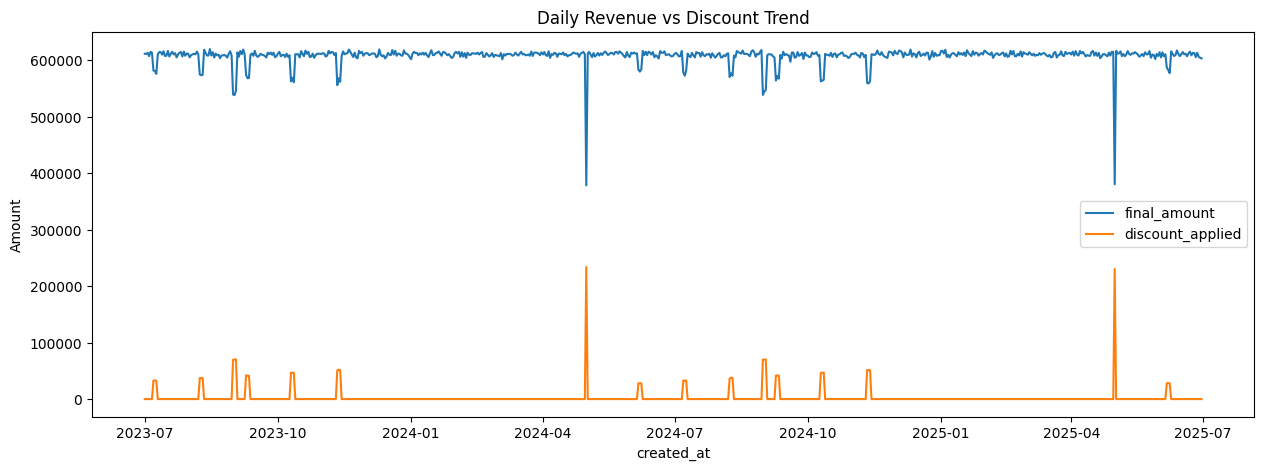

3598

In [4]:
daily_trend = (
    df_transaction
    .groupby(df_transaction['created_at'].dt.date)
    .agg({
        'final_amount': 'sum',
        'discount_applied': 'sum',
        'transaction_id': 'count'
    })
)
gc.collect()
daily_trend[
    ['final_amount', 'discount_applied']
].plot(figsize=(15,5))

plt.title('Daily Revenue vs Discount Trend')
plt.ylabel('Amount')

plt.show()
gc.collect()

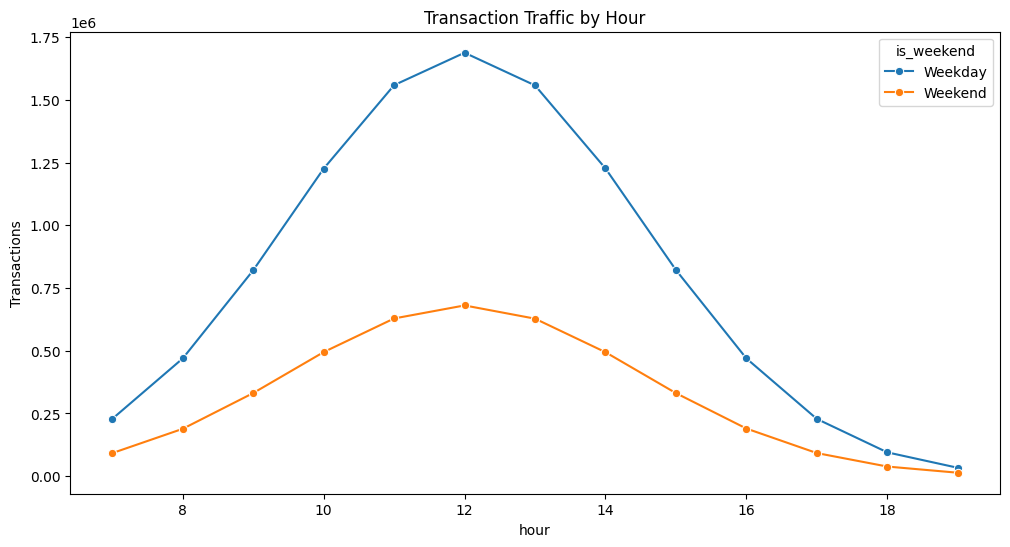

173

In [5]:
hourly_dist = (
    df_Master_FE
    .groupby(['hour', 'is_weekend'])['transaction_id']
    .nunique()
    .reset_index(name='trans_count')
)
gc.collect()
plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_dist,
    x='hour',
    y='trans_count',
    hue='is_weekend',
    marker='o'
)

plt.title('Transaction Traffic by Hour')
plt.ylabel('Transactions')

plt.show()
gc.collect()

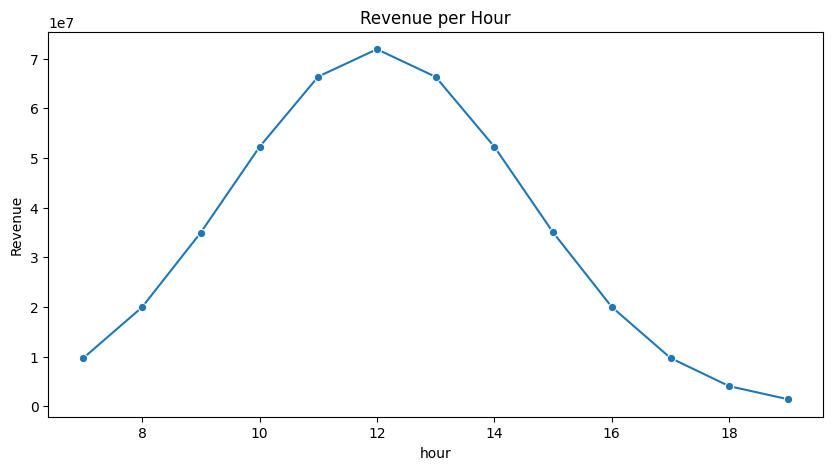

156

In [6]:
hourly_revenue = (
    df_transaction
    .groupby('hour')['final_amount']
    .sum()
    .reset_index()
)
gc.collect()
plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly_revenue,
    x='hour',
    y='final_amount',
    marker='o'
)

plt.title('Revenue per Hour')
plt.ylabel('Revenue')

plt.show()
gc.collect()

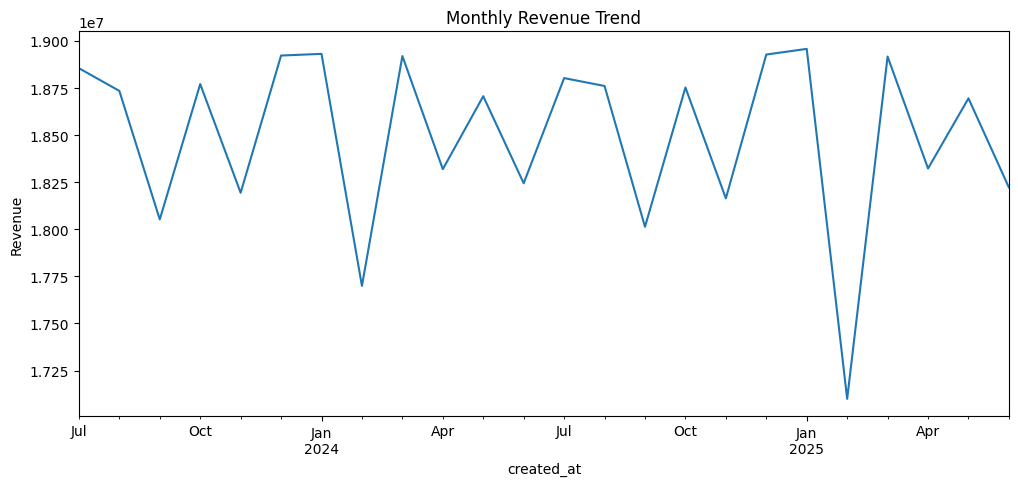

4966

In [7]:
monthly_trend = (
    df_transaction
    .groupby(
        df_transaction['created_at'].dt.to_period('M')
    )['final_amount']
    .sum()
)
gc.collect()
monthly_trend.plot(figsize=(12,5))

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')

plt.show()
gc.collect()

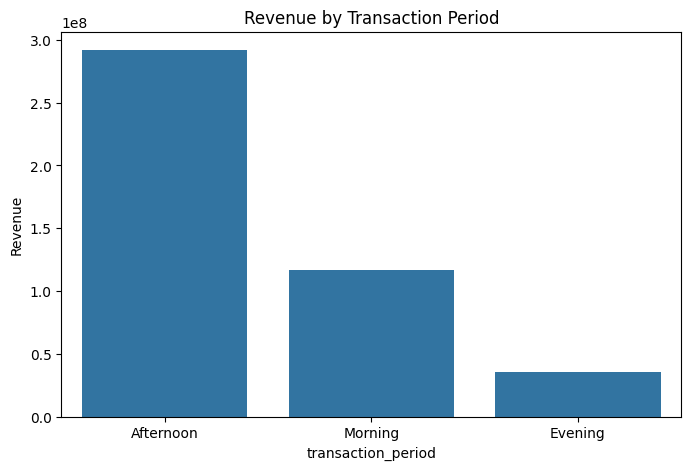

147

In [8]:
period_rev = (
    df_transaction
    .groupby('transaction_period')['final_amount']
    .sum()
    .sort_values(ascending=False)
)
gc.collect()
plt.figure(figsize=(8,5))

sns.barplot(
    x=period_rev.index,
    y=period_rev.values
)

plt.title('Revenue by Transaction Period')
plt.ylabel('Revenue')

plt.show()
gc.collect()

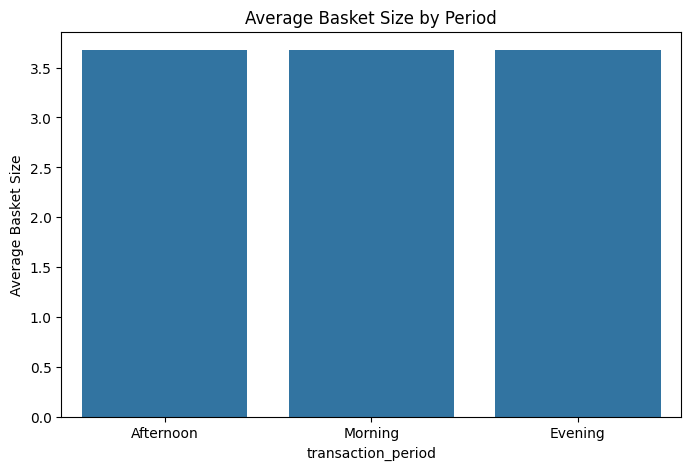

147

In [9]:
basket_period = (
    df_transaction
    .groupby('transaction_period')['basket_size']
    .mean()
    .sort_values(ascending=False)
)
gc.collect()
plt.figure(figsize=(8,5))

sns.barplot(
    x=basket_period.index,
    y=basket_period.values
)

plt.title('Average Basket Size by Period')
plt.ylabel('Average Basket Size')

plt.show()
gc.collect()

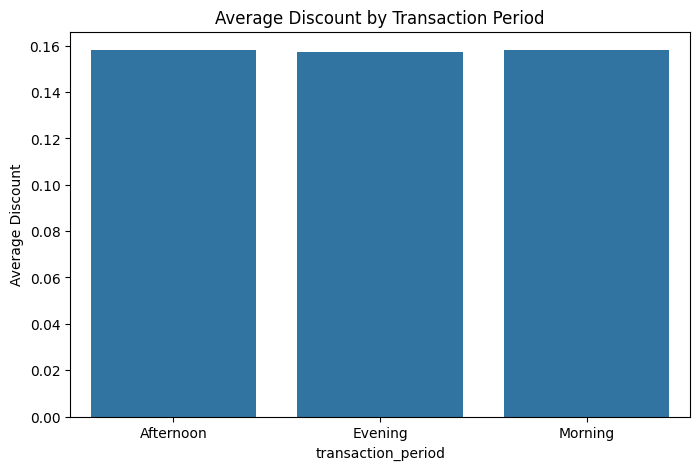

147

In [10]:
voucher_period = (
    df_transaction
    .groupby('transaction_period')['discount_applied']
    .mean()
)
gc.collect()
plt.figure(figsize=(8,5))

sns.barplot(
    x=voucher_period.index,
    y=voucher_period.values
)

plt.title('Average Discount by Transaction Period')
plt.ylabel('Average Discount')

plt.show()
gc.collect()

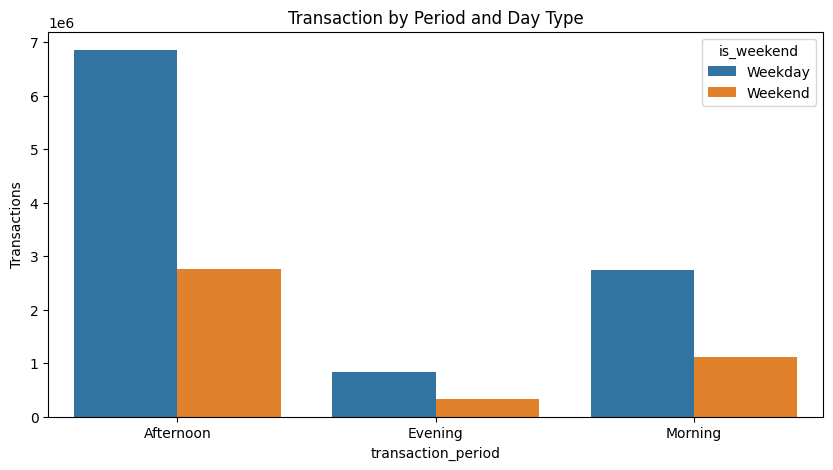

155

In [11]:
period_weekend = (
    df_Master_FE
    .groupby(
        ['transaction_period', 'is_weekend']
    )['transaction_id']
    .nunique()
    .reset_index(name='total_trans')
)
gc.collect()
plt.figure(figsize=(10,5))

sns.barplot(
    data=period_weekend,
    x='transaction_period',
    y='total_trans',
    hue='is_weekend'
)

plt.title('Transaction by Period and Day Type')
plt.ylabel('Transactions')

plt.show()
gc.collect()

## Customer Analysis

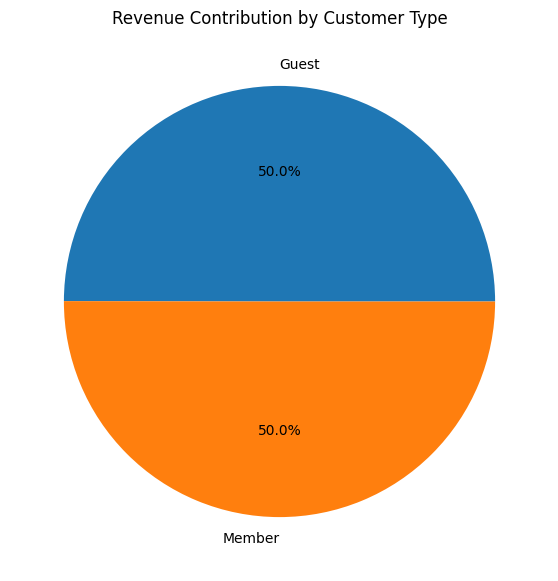

1840

In [12]:
customer_rev = (
    df_transaction
    .groupby('member_status')['final_amount']
    .sum()
)
gc.collect()
plt.figure(figsize=(7,7))

plt.pie(
    customer_rev,
    labels=customer_rev.index,
    autopct='%1.1f%%'
)

plt.title('Revenue Contribution by Customer Type')

plt.show()
gc.collect()

In [13]:
member_behavior = (
    df_transaction
    .groupby('member_status')
    .agg({
        'transaction_id': 'count',
        'final_amount': 'mean'
    })
)
gc.collect()
print(member_behavior)

               transaction_id  final_amount
member_status                              
Guest                 7310827     30.348576
Member                7312864     30.373737


In [14]:
repeat_cust = (
    df_rfm['is_repeat_customer']
    .value_counts()
)
gc.collect()
print(repeat_cust)

is_repeat_customer
Repeat Customer      1536904
One-Time Customer     659353
Name: count, dtype: int64


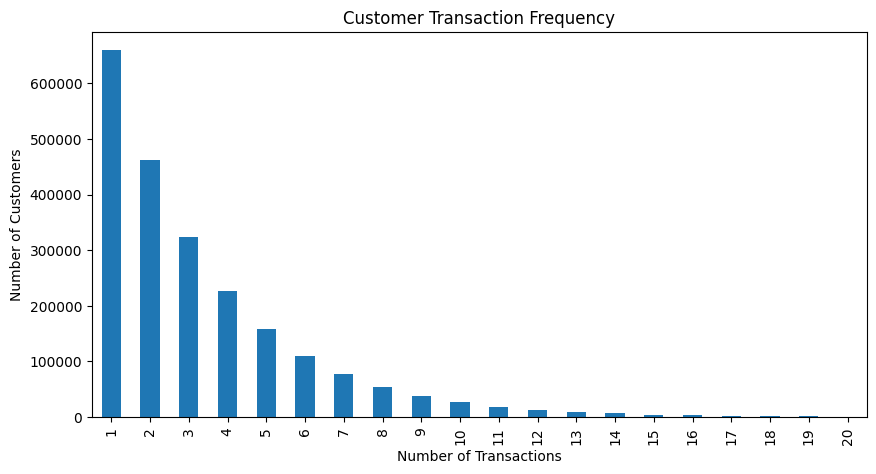

5393

In [15]:
repeat_dist = (
    df_rfm['Frequency']
    .value_counts()
    .sort_index()
)
gc.collect()
plt.figure(figsize=(10,5))

repeat_dist.head(20).plot(kind='bar')

plt.title('Customer Transaction Frequency')

plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')

plt.show()
gc.collect()

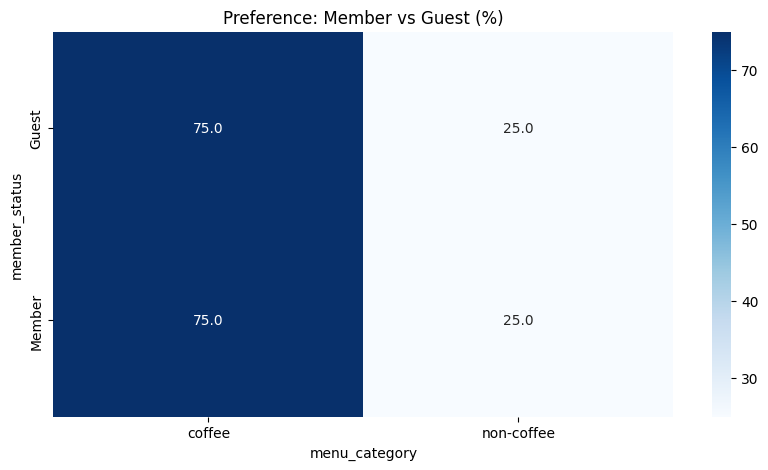

4312

In [16]:
member_pref = (
    df_Master_FE
    .groupby(
        ['member_status', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)
gc.collect()
member_pref_pct = (
    member_pref
    .div(member_pref.sum(axis=1), axis=0)
    * 100
)
gc.collect()
plt.figure(figsize=(10,5))

sns.heatmap(
    member_pref_pct,
    annot=True,
    fmt=".1f",
    cmap='Blues'
)

plt.title('Preference: Member vs Guest (%)')

plt.show()
gc.collect()


## Product Analysis

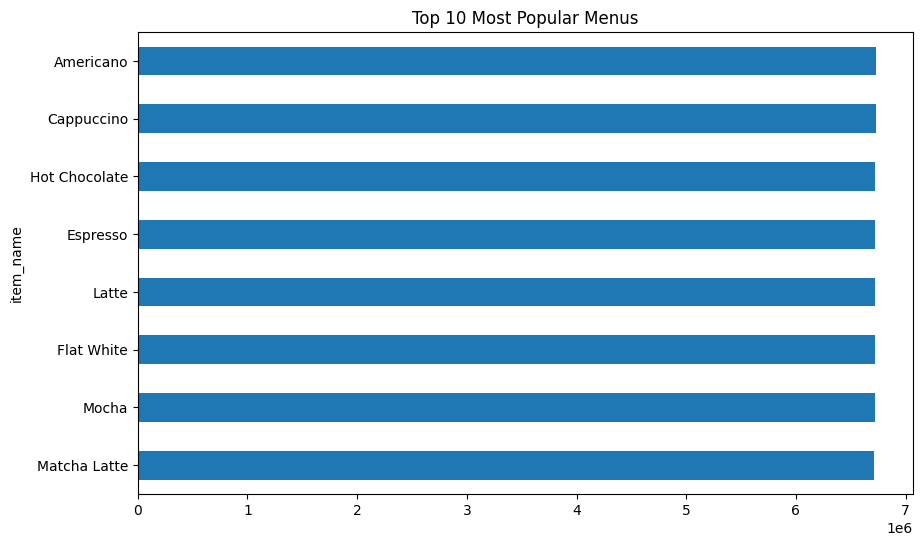

3767

In [17]:
top_10_menu = (
    df_Master_FE
    .groupby('item_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
gc.collect()
plt.figure(figsize=(10,6))

top_10_menu.plot(kind='barh')

plt.gca().invert_yaxis()

plt.title('Top 10 Most Popular Menus')

plt.show()  
gc.collect()

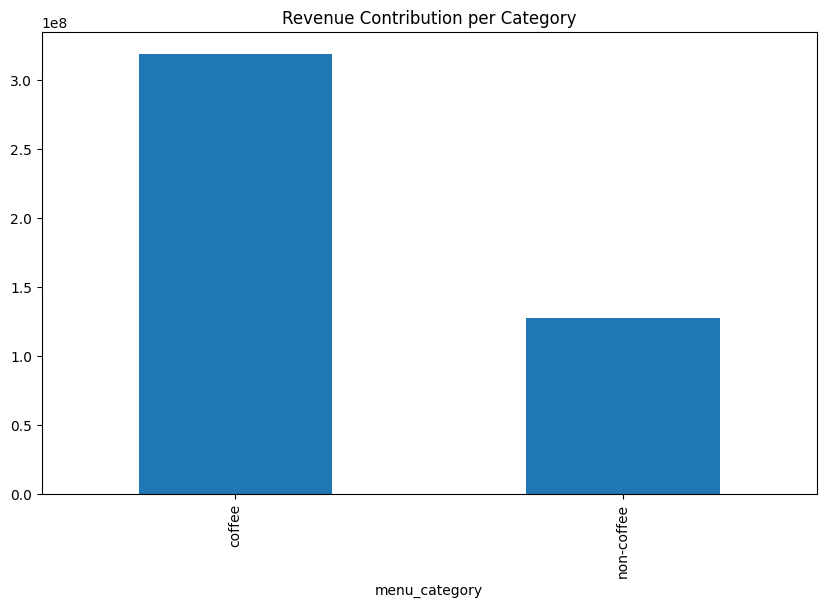

In [18]:
category_revenue = (
    df_Master_FE
    .groupby('menu_category')['subtotal']
    .sum()
    .sort_values(ascending=False)
)
gc.collect()
plt.figure(figsize=(10,6))

category_revenue.plot(kind='bar')

plt.title('Revenue Contribution per Category')

plt.show()

In [19]:
top_menu_category = (
    df_Master_FE
    .groupby(
        ['menu_category', 'item_name']
    )['quantity']
    .sum()
    .reset_index()
)
gc.collect()
top_menu_category = (
    top_menu_category
    .sort_values(
        ['menu_category', 'quantity'],
        ascending=[True, False]
    )
    .groupby('menu_category')
    .head(3)
)

print(top_menu_category)


  menu_category      item_name  quantity
0        coffee      Americano   6729047
1        coffee     Cappuccino   6726195
2        coffee       Espresso   6720513
6    non-coffee  Hot Chocolate   6723022
7    non-coffee   Matcha Latte   6715195


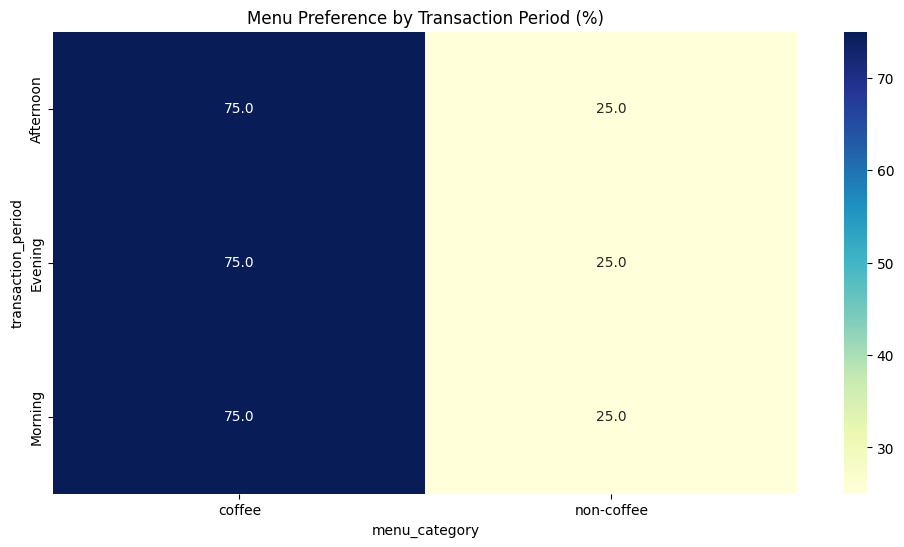

4525

In [20]:
menu_period = (
    df_Master_FE
    .groupby(
        ['transaction_period', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)
gc.collect()
menu_period_pct = (
    menu_period
    .div(menu_period.sum(axis=1), axis=0)
    * 100
)
gc.collect()
plt.figure(figsize=(12,6))

sns.heatmap(
    menu_period_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Menu Preference by Transaction Period (%)')

plt.show()
gc.collect()

## Spatial Analysis

In [21]:
city_rev = (
    df_transaction
    .groupby('city')['final_amount']
    .sum()
    .sort_values(ascending=False)
)
gc.collect()
print(city_rev.head(10))

city
Seksyen 21              44436752.0
Bandar Seri Mulia       44436536.0
Taman Damansara         44434224.0
Kampung Changkat        44418092.0
USJ 57W                 44406984.0
Alam Tun Hussein Onn    44399224.0
Kondominium Putra       44376848.0
PJS8                    44371544.0
Damansara Saujana       44367976.0
USJ 89q                 44344004.0
Name: final_amount, dtype: float32


city
USJ 57W                 30.374550
Kondominium Putra       30.371117
PJS8                    30.370729
Taman Damansara         30.369791
Bandar Seri Mulia       30.369276
Kampung Changkat        30.363310
Damansara Saujana       30.357046
USJ 89q                 30.356512
Alam Tun Hussein Onn    30.341141
Seksyen 21              30.338156
Name: final_amount, dtype: float32


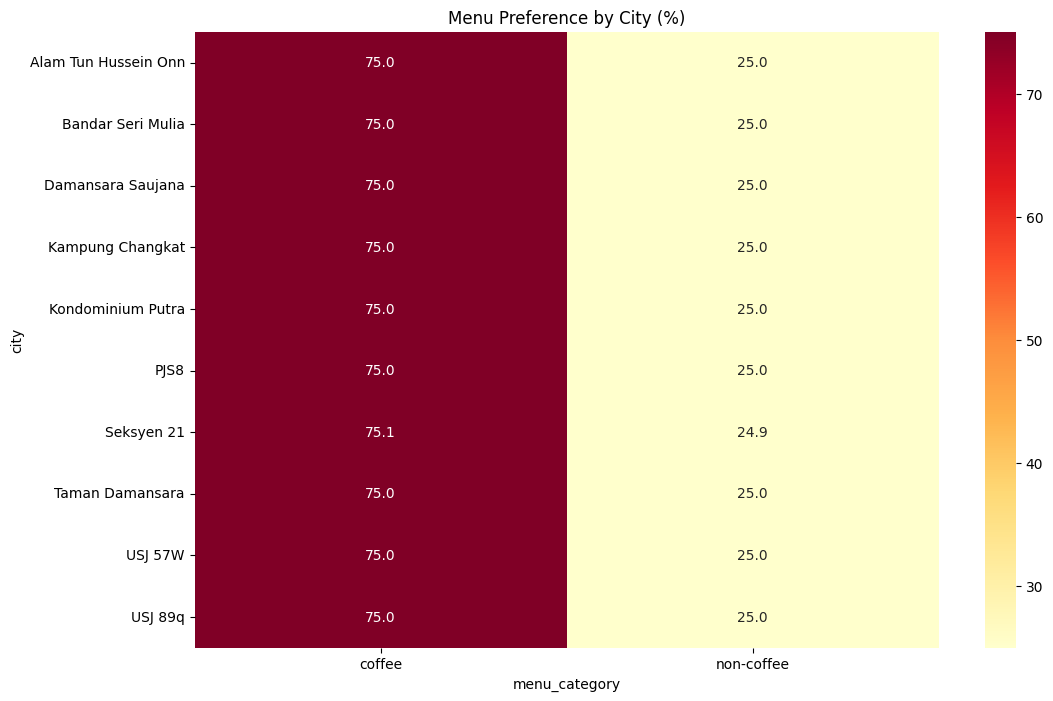

6046

In [22]:
city_atv = (
    df_transaction
    .groupby('city')['final_amount']
    .mean()
    .sort_values(ascending=False)
)
gc.collect()
print(city_atv.head(10))

city_menu_pref = (
    df_Master_FE
    .groupby(
        ['city', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)
gc.collect()
city_pref_pct = (
    city_menu_pref
    .div(city_menu_pref.sum(axis=1), axis=0)
    * 100
)
gc.collect()
plt.figure(figsize=(12,8))

sns.heatmap(
    city_pref_pct,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd'
)

plt.title('Menu Preference by City (%)')

plt.show()
gc.collect()


## Payment Analysis

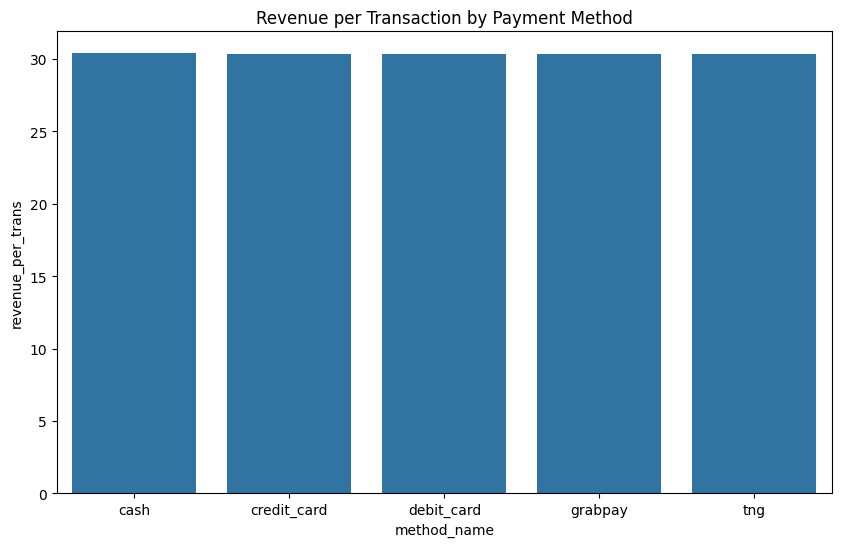

150

In [23]:
payment_stats = (
    df_transaction
    .groupby('method_name')
    .agg({
        'transaction_id': 'count',
        'final_amount': 'sum'
    })
    .rename(columns={
        'transaction_id': 'total_trans'
    })
)
gc.collect()
total_qty_payment = (
    df_Master_FE
    .groupby('method_name')['quantity']
    .sum()
)
gc.collect()
payment_behavior = payment_stats.copy()
gc.collect()
payment_behavior['total_quantity'] = total_qty_payment
gc.collect()
payment_behavior['avg_items_per_trans'] = (
    payment_behavior['total_quantity']
    / payment_behavior['total_trans']
)
gc.collect()
payment_behavior['revenue_per_trans'] = (
    payment_behavior['final_amount']
    / payment_behavior['total_trans']
)
gc.collect()
plt.figure(figsize=(10,6))

sns.barplot(
    x=payment_behavior.index,
    y=payment_behavior['revenue_per_trans']
)

plt.title('Revenue per Transaction by Payment Method')

plt.show()
gc.collect()

## Promotion Analysis

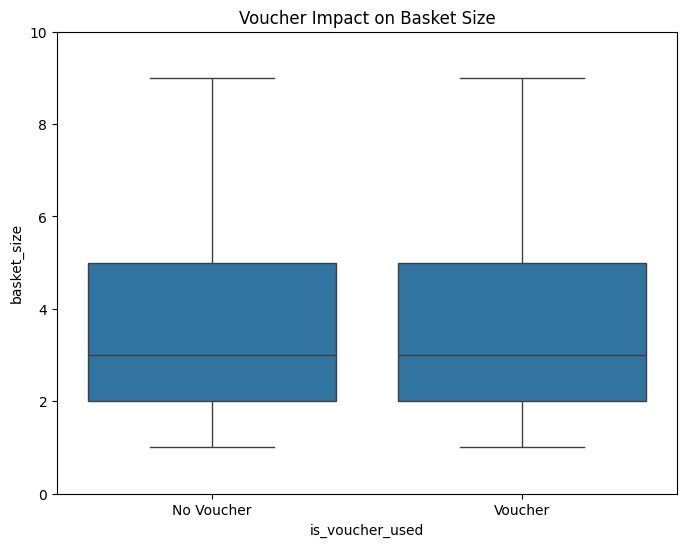

               discount_applied  final_amount  discount_ratio (%)
member_status                                                    
Guest                  0.172169     30.348576                0.56
Member                 0.143843     30.373737                0.47


In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_transaction,
    x='is_voucher_used',
    y='basket_size'
)

plt.title('Voucher Impact on Basket Size')

plt.ylim(0,10)

plt.show()
gc.collect()
# Voucher Sensitivity
voucher_sensitivity = (
    df_transaction
    .groupby('member_status')
    .agg({
        'discount_applied': 'mean',
        'final_amount': 'mean'
    })
)
gc.collect()
voucher_sensitivity['discount_ratio (%)'] = (
    voucher_sensitivity['discount_applied']
    /
    (
        voucher_sensitivity['final_amount']
        +
        voucher_sensitivity['discount_applied']
    )
    * 100
).round(2)
gc.collect()
print(voucher_sensitivity)

## Others Analytics

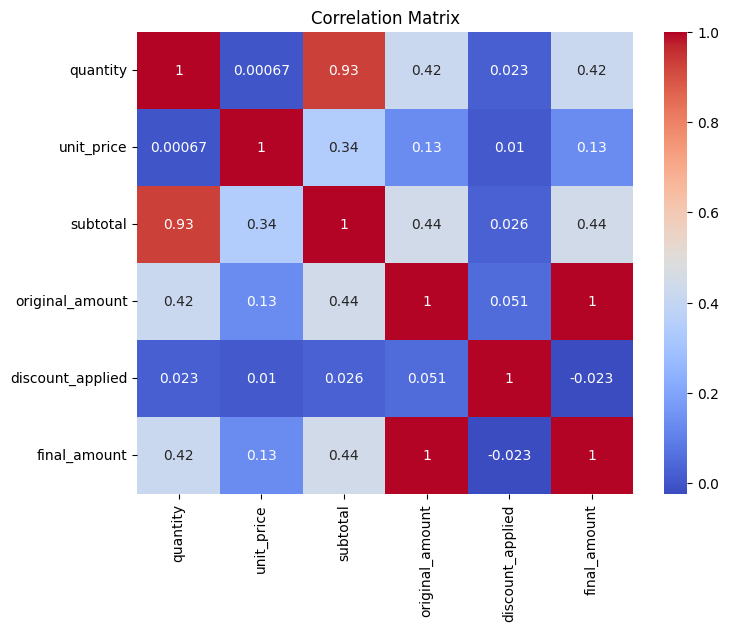

6913

In [25]:
df_sample = (
    df_Master_FE
    .sample(frac=0.01, random_state=42)
)
gc.collect()
corr_cols = [
    'quantity',
    'unit_price',
    'subtotal',
    'original_amount',
    'discount_applied',
    'final_amount'
]
gc.collect()
corr_matrix = (
    df_sample[corr_cols]
    .corr()
)
gc.collect()
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()
gc.collect()

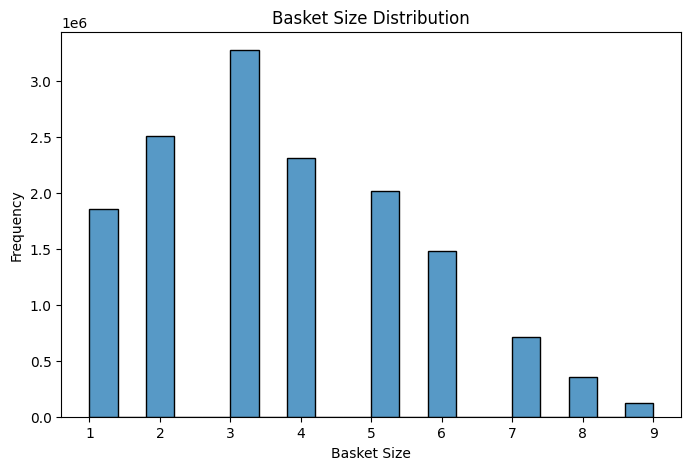

100

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_transaction['basket_size'],
    bins=20
)

plt.title('Basket Size Distribution')

plt.xlabel('Basket Size')
plt.ylabel('Frequency')

plt.show()
gc.collect()

In [29]:
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1])
gc.collect()
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
gc.collect()
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])
gc.collect()
def segment_customer(df):
    if df['F_Score'] == 4 and df['M_Score'] == 4:
        return 'Champions'
    elif df['R_Score'] == 1:
        return 'At Risk'
    elif df['F_Score'] >= 3:
        return 'Loyal'
    else:
        return 'Regular'
gc.collect()
df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)
gc.collect()
print(df_rfm['Segment'].value_counts())

Segment
Regular      817475
Champions    549064
At Risk      418021
Loyal        411697
Name: count, dtype: int64


In [30]:
gc.collect()

0